In [1]:

import numpy as np 


Validation Accuracy: 96.36%
Cross-validation scores: [0.95843455 0.96248313 0.95897436 0.95924426 0.96679266]
Mean accuracy: 0.9611857917763341
Std deviation: 0.00314163421863161
Train shape: (18524, 9)
Test shape: (6175, 8)

Train describe:
                  id  Time_spent_Alone  Social_event_attendance  Going_outside  \
count  18524.000000      17334.000000             17344.000000   17058.000000   
mean    9261.500000          3.137764                 5.265106       4.044319   
std     5347.562529          3.003786                 2.753359       2.062580   
min        0.000000          0.000000                 0.000000       0.000000   
25%     4630.750000          1.000000                 3.000000       3.000000   
50%     9261.500000          2.000000                 5.000000       4.000000   
75%    13892.250000          4.000000                 8.000000       6.000000   
max    18523.000000         11.000000                10.000000       7.000000   

       Friends_circle_size

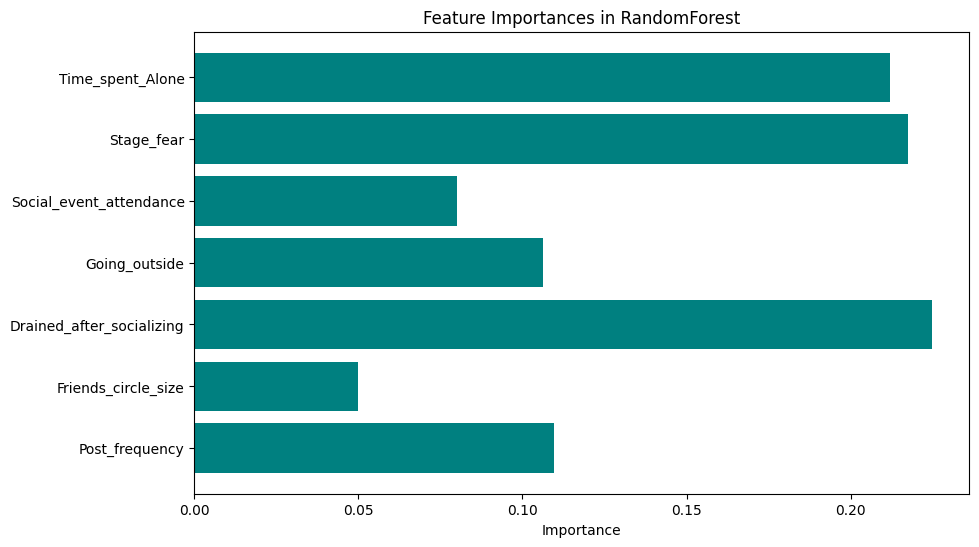

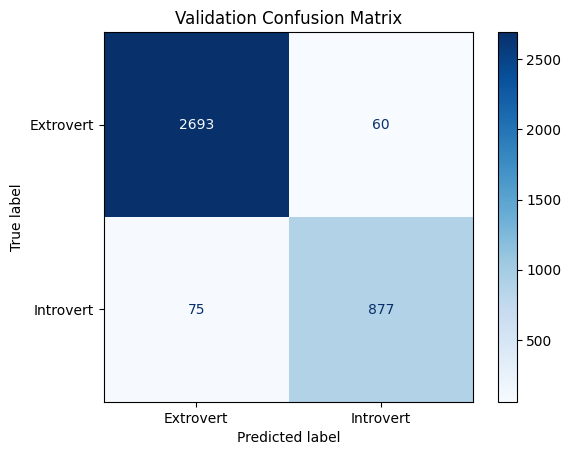

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load data
train = pd.read_csv('/kaggle/input/playground-series-s5e7/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e7/test.csv')

# Features and Target
X = train[['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
           'Going_outside', 'Drained_after_socializing',
           'Friends_circle_size', 'Post_frequency']]
Y = train['Personality']

# Impute missing values
imputer = SimpleImputer(strategy='most_frequent')
X = imputer.fit_transform(X)
X = pd.DataFrame(X, columns=['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
                             'Going_outside', 'Drained_after_socializing',
                             'Friends_circle_size', 'Post_frequency'])

# Encode categorical
encoder_target = LabelEncoder()
encoder = OrdinalEncoder()
X[['Stage_fear', 'Drained_after_socializing']] = encoder.fit_transform(X[['Stage_fear', 'Drained_after_socializing']])
y_encoded = encoder_target.fit_transform(Y)

# Split train/test (for evaluation only)
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)


 #Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on validation set
y_pred = model.predict(X_val)

# Accuracy
acc = accuracy_score(y_val, y_pred)
print(f"\nValidation Accuracy: {acc:.2%}")

# Cross-validation
scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())
print("Std deviation:", scores.std())

# --- Prepare real test.csv for submission ---
# Preprocess test (like we did with X)
test_features = test[['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
                      'Going_outside', 'Drained_after_socializing',
                      'Friends_circle_size', 'Post_frequency']]
test_features = imputer.transform(test_features)
test_features = pd.DataFrame(test_features, columns=X.columns)
test_features[['Stage_fear', 'Drained_after_socializing']] = encoder.transform(
    test_features[['Stage_fear', 'Drained_after_socializing']])

# Predict on real test set
test_predictions = model.predict(test_features)
test_predictions_labels = encoder_target.inverse_transform(test_predictions)

# Handle submission ID
submission = pd.DataFrame({'id': test['id'], 'Personality': test_predictions_labels})

# Save CSV
submission.to_csv('submission.csv', index=False)

# Shape & describe
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain describe:\n", train.describe())

# Only if test is still a DataFrame
if isinstance(test, pd.DataFrame):
    print("\nTest describe:\n", test.describe())
   

# Feature Importance
importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='teal')
plt.xlabel('Importance')
plt.title('Feature Importances in RandomForest')
plt.gca().invert_yaxis()
plt.show()
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_val, y_val,
                                      display_labels=encoder_target.classes_,
                                      cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.show()


